## Evaluation Heatmap
Same as `1. Evaluation_group_model.ipynb` but for NNLS method. 


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.globals as gl
import matplotlib.pyplot as plt

### Loading group models

In [5]:
method = 'NNLS'
train_ds_list = ["MDTB", "Language", "Social", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]
eval_ds_list = ["MDTB", "Language", "Social", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]
eval_names = ["MDTB", "Languagelocalizer", "Socialsocial", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]
df_all = pd.DataFrame()
for i, dataset_name in enumerate(train_ds_list):

    # Load avg performances
    df = rm.comb_eval(models=[dataset_name+"-group-Cavg"],methods=[method],eval_data=eval_names,cerebellum='MNISymC3')
    df_all = pd.concat([df_all, df], ignore_index=True)
df_all.logalpha.fillna(-2.0, inplace=True)

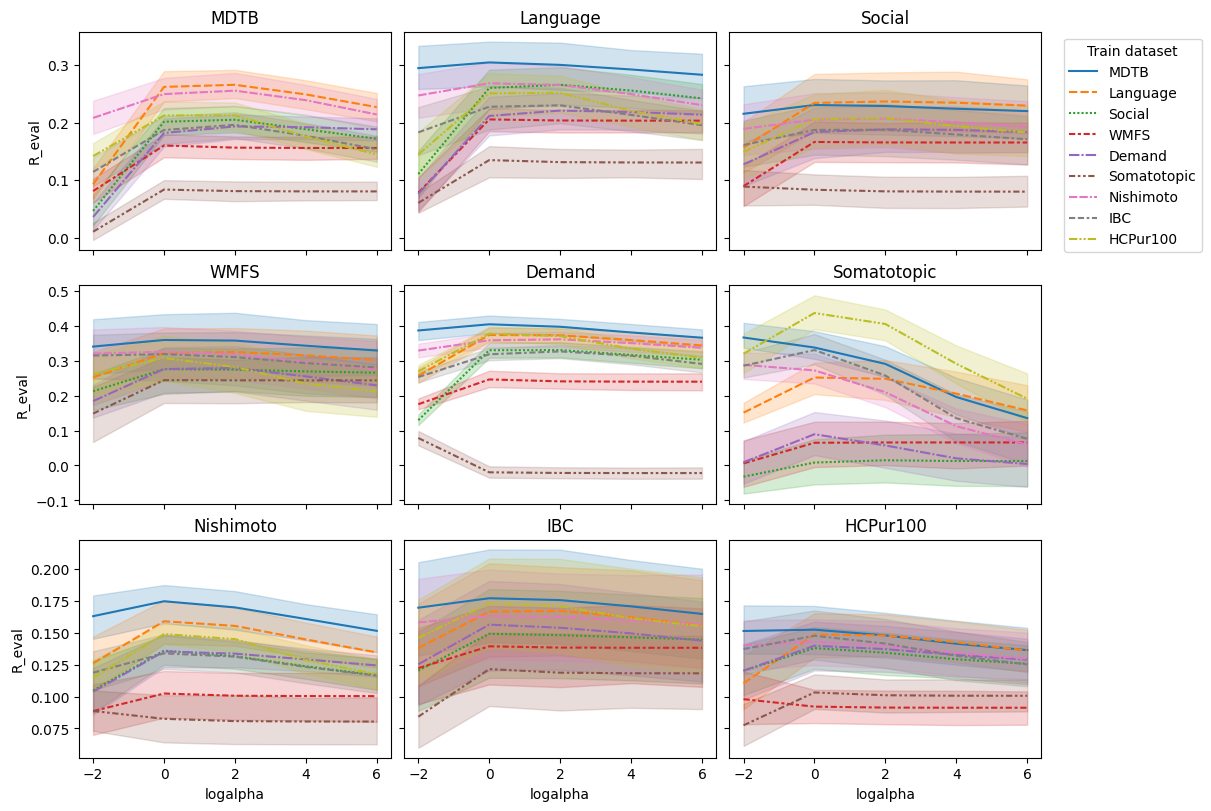

In [6]:
fig, axes = plt.subplots(np.ceil(len(eval_ds_list) / 3).astype(int), 3, figsize=(12, 8), sharey='row', sharex='col', constrained_layout=True)
for i,ed in enumerate(eval_ds_list):
    # Left subplot
    ax = axes[i // 3, i % 3]
    df_to_plot = df_all[(df_all.eval_dataset==ed) & ((df_all.train_dataset!=ed)
                                                     | (df_all.model.str.contains('loo')))]
    sns.lineplot(data=df_to_plot, y='R_eval', x='logalpha', hue='train_dataset', style='train_dataset',
                     hue_order=train_ds_list, style_order=train_ds_list, ax=ax)
    ax.set_title(ed)

    if i == 2:
        ax.legend(title='Train dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.legend_.remove()

# Remove extra subplots if more than len(eval_ds_list)
if len(eval_ds_list) < axes.size:
    for j in range(len(eval_ds_list), axes.size):
        fig.delaxes(axes.flatten()[j])

### Find best hyperparameter

In [7]:
A = pd.pivot_table(df_all, index=['train_dataset'],columns=['logalpha'],values=['R_eval'],aggfunc='mean').reindex(train_ds_list)
display(A)
B = np.nan_to_num(A.values)
ind = B.argmax(axis=1)
log_a = np.array(A.columns.get_level_values(1)[ind])
bestla = pd.DataFrame(log_a,index=A.index,columns=['best_logalpha'])
display(bestla)
df_all['isbest'] = df_all.logalpha.values == bestla.loc[df_all.train_dataset].values.flatten()

R_eval                                        
logalpha           -2.0       0.0       2.0       4.0       6.0
train_dataset                                                  
MDTB           0.256151  0.264730  0.258491  0.244937  0.233710
Language       0.162270  0.244721  0.245183  0.234715  0.221660
Social         0.112107  0.208649  0.208690  0.199861  0.191330
WMFS           0.106343  0.156481  0.154227  0.153893  0.153847
Demand         0.104244  0.173041  0.174059  0.167073  0.160081
Somatotopic    0.075963  0.089453  0.087200  0.086831  0.086780
Nishimoto      0.225191  0.241046  0.238088  0.223897  0.209830
IBC            0.187168  0.223403  0.220762  0.203210  0.186741
HCPur100       0.199653  0.276349  0.269995  0.235287  0.209582

,best_logalpha
train_dataset,
MDTB,0.0
Language,2.0
Social,2.0
WMFS,0.0
Demand,2.0
Somatotopic,0.0
Nishimoto,0.0
IBC,0.0
HCPur100,0.0


In [9]:
### load global model
df_global = pd.DataFrame()
for i,ds in enumerate(eval_ds_list):
    d = gl.datasets.index(ds)
    train_dscode = ''.join(gl.dscode[:d]+gl.dscode[d+1:])
    df = rm.comb_eval(models=[f'{train_dscode}-global-Cavg'], methods=[method], eval_data=[eval_names[i]], cerebellum='MNISymC3')
    df_global = pd.concat([df_global, df], ignore_index=True)

df_global['model'] = 'Global'
df_global.loc[df_global['logalpha'].isnull(), 'logalpha'] = -np.inf

In [10]:
A = pd.pivot_table(df_global, index=['model'], columns=['logalpha'],values=['R_eval'],aggfunc='mean')
display(A)
B = np.nan_to_num(A.values)
ind = B.argmax(axis=1)
log_a = np.array(A.columns.get_level_values(1)[ind])
bestla = pd.DataFrame(log_a,index=A.index,columns=['best_logalpha'])
display(bestla)
df_global['isbest'] = df_global.logalpha.values == bestla.loc[df_global.model].values.flatten()

R_eval                             
logalpha     -inf      0.0       1.0       2.0
model                                         
Global    0.29041  0.29331  0.292853  0.290881

,best_logalpha
model,
Global,0.0


### Evaluation Heatmap at best Hyperparameter 

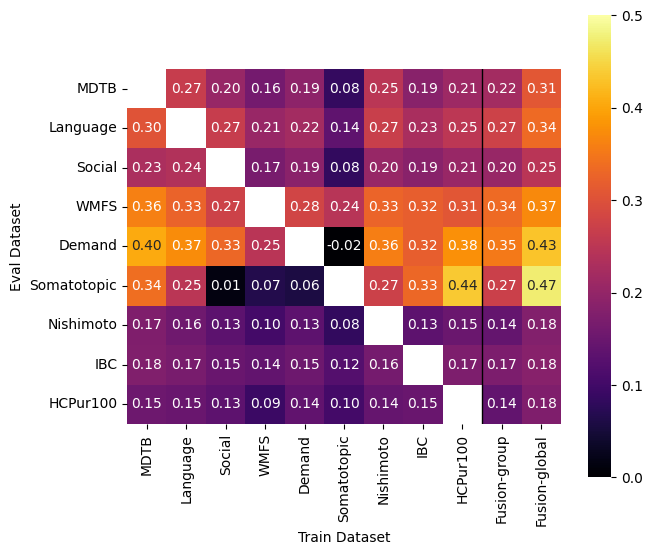

In [11]:
plt.figure(figsize=(7,6))

df_fuse = rm.comb_eval(models=['Fus-lodo-group-Cavg'], methods=[method], eval_data=['all'], cerebellum='MNISymC3')
df_fuse['train_dataset'] = 'Fusion-group'
df_global['train_dataset'] = 'Fusion-global'
df_to_plot = pd.concat([df_all[df_all.isbest], df_fuse, df_global[df_global.isbest]], ignore_index=True)

V = pd.pivot_table(df_to_plot, columns='train_dataset', index='eval_dataset', values='R_eval')
V = V.reindex(eval_ds_list, axis=0)
V = V.reindex(train_ds_list+['Fusion-group', 'Fusion-global'], axis=1)

sns.heatmap(V.values, annot=True, fmt=".2f", cmap='inferno', vmin=0, vmax=0.5, 
            xticklabels=V.columns.values, 
            yticklabels=V.index.values, square=True)
plt.axvline(x=V.shape[1] - 2, color='black', linewidth=1)
plt.xlabel('Train Dataset');
plt.ylabel('Eval Dataset');

### Evaluation Heatmap relative to the noise ceiling


In [12]:
# As a best noise ceiling estimate, we use the average of the upper and lower bounds
# Note that we could replace this with the square root of the average inter-subject correlation for the paper. 
df_to_plot['group_noiseceil_Y']=(df_to_plot['group_noiseceil_Y_upper'] + df_to_plot['group_noiseceil_Y_lower']) /2 
# Noise ceiling for each eval dataset
NC = pd.pivot_table(df_to_plot,values='group_noiseceil_Y',index='eval_dataset')
NC = NC.reindex(eval_ds_list, axis=0)
print(NC)

              group_noiseceil_Y
eval_dataset                   
MDTB                   0.405417
Language               0.412114
Social                 0.301559
WMFS                   0.449942
Demand                 0.484896
Somatotopic            0.688174
Nishimoto              0.336324
IBC                    0.281408
HCPur100               0.246714


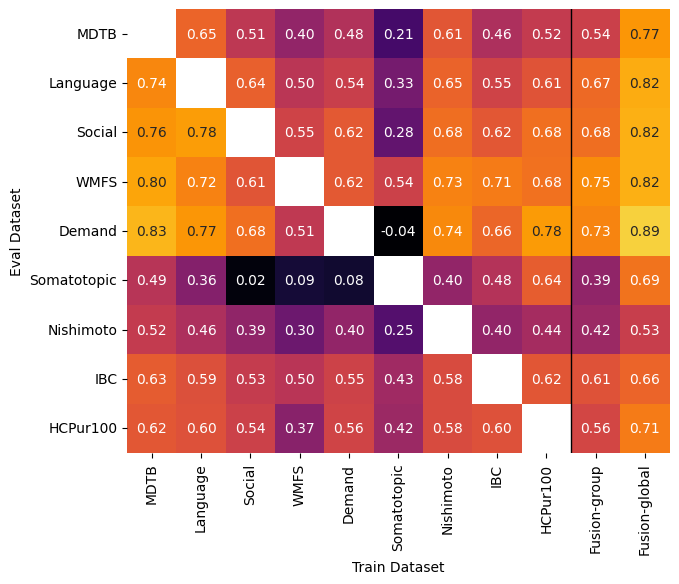

In [13]:
plt.figure(figsize=(7,6))
corrR = V.values/ NC.values
sns.heatmap(corrR, annot=True, fmt=".2f", cmap='inferno', vmin=0, vmax=1.0, 
            xticklabels=V.columns.values, 
            yticklabels=V.index.values, square=True, cbar=False)
plt.axvline(x=V.shape[1] - 2, color='black', linewidth=1)
plt.xlabel('Train Dataset');
plt.ylabel('Eval Dataset');

# plt.savefig(f'{gl.fig_dir}/heatmap_normalized.pdf', bbox_inches='tight')

### Overall Evaluation

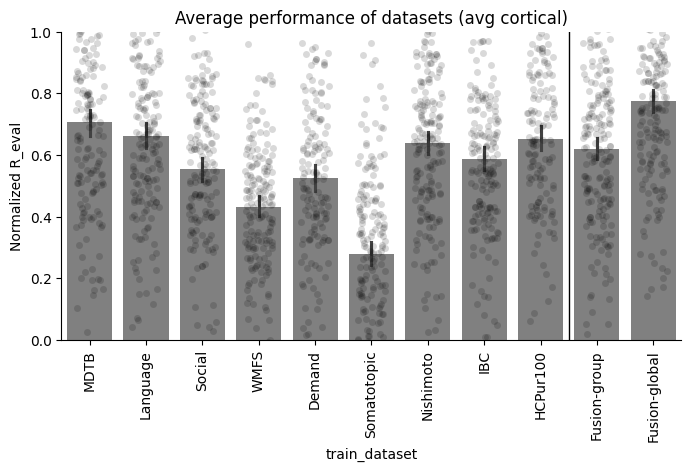

In [17]:
df_to_plot['mean_group_noiseceil_Y'] = df_to_plot['eval_dataset'].map(NC['group_noiseceil_Y'])

plt.figure(figsize=(8, 4))
sns.barplot(data=df_to_plot, x='train_dataset', y=df_to_plot['R_eval'] / df_to_plot['mean_group_noiseceil_Y'], order=train_ds_list+["Fusion-group", "Fusion-global"], color=[0.5,0.5,0.5])
sns.stripplot(data=df_to_plot, x='train_dataset', y=df_to_plot['R_eval'] / df_to_plot['mean_group_noiseceil_Y'], color=[0,0,0], alpha=0.15, jitter=0.25)
ax = plt.gca()
ax.set_xticks(np.arange(len(train_ds_list+["Fusion-group", "Fusion-global"])))
a = ax.set_xticklabels(train_ds_list+["Fusion-group", "Fusion-global"], rotation=90)
# remove top and right spines
ax.axvline(x=8.5, color='black', linewidth=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Average performance of datasets (avg cortical)')
ax.set_ylabel('Normalized R_eval')
ax.set_ylim(0, 1);